Enter target node:  3
Enter initial position:  0
Enter number of time steps:  3


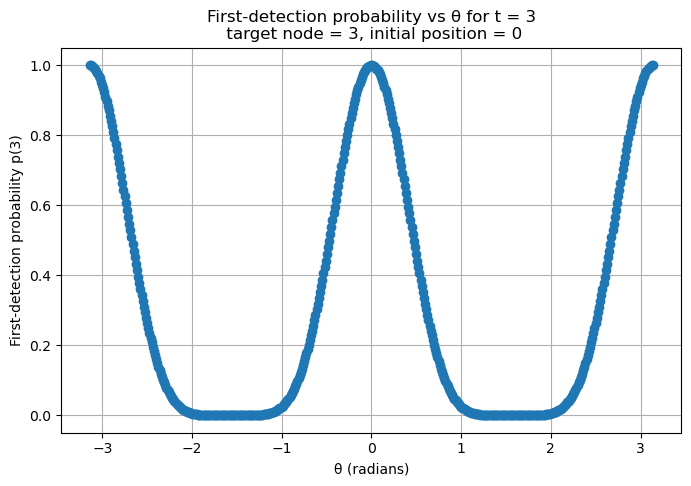

In [5]:
### Initialisers
import numpy as np
import matplotlib.pyplot as plt

# Adjoint
def dagger(A):
    return A.conj().T

# Kronecker tensor product
def kron(A, B):
    return np.kron(A, B)

# Rotation matrix
def rotation(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ], dtype=complex)

# Changeable theta values
theta_vals = np.linspace(-np.pi, np.pi, 500)

# Choose values
target = int(input("Enter target node: "))
init_pos = int(input("Enter initial position: "))
t = int(input("Enter number of time steps: "))

L = 100
Npos = 2 * L + 1
Ncoin = 2
dim = Npos * Ncoin

# Map positions to indices
def pos_index(i):
    return i + L

# Shift operator
S = np.zeros((dim, dim), dtype=complex)

for i in range(-L, L + 1):
    if i + 1 <= L:
        S[2 * pos_index(i + 1), 2 * pos_index(i)] = 1  # Move right
    if i - 1 >= -L:
        S[2 * pos_index(i - 1) + 1, 2 * pos_index(i) + 1] = 1  # Move left

# Projection operators
P_pos = np.zeros((Npos, Npos), dtype=complex)
P_pos[pos_index(target), pos_index(target)] = 1

I_coin = np.eye(2, dtype=complex)
P = kron(P_pos, I_coin)
Q = np.eye(dim, dtype=complex) - P

# Initial state (density matrix)
rho_pos = np.zeros((Npos, Npos), dtype=complex)
rho_pos[pos_index(init_pos), pos_index(init_pos)] = 1

rho_coin = np.array([[1, 0],
                   [0, 0]], dtype=complex)

rho0 = kron(rho_pos, rho_coin)

# Calculate p(t)
p_vals = []

for theta in theta_vals:

    R = rotation(theta)
    U = S @ kron(np.eye(Npos, dtype=complex), R)

    if init_pos == target:
        if t == 0:
            p_t = 1.0
        else:
            p_t = 0.0
    else:
        QU = Q @ U
        QU_power = np.linalg.matrix_power(QU, t - 1)
        A = P @ U @ QU_power
        B = dagger(A)
        p_t = np.real(np.trace(A @ rho0 @ B))

    p_vals.append(p_t)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(theta_vals, p_vals, marker='o')
plt.xlabel("θ (radians)")
plt.ylabel(f"First-detection probability p({t})")
plt.title(f"First-detection probability vs θ for t = {t}\n target node = {target}, initial position = {init_pos}")
plt.grid()
plt.show()


In [6]:
# Find maxima
from scipy.signal import find_peaks

p_vals = np.array(p_vals)
theta_vals = np.array(theta_vals)

peaks, _ = find_peaks(p_vals)

theta_peaks = theta_vals[peaks]
p_peaks = p_vals[peaks]

print("All local maxima:")
for t, p in zip(theta_peaks, p_peaks):
    print("theta =", t, "   p =", p)

All local maxima:
theta = -0.006295776860901547    p = 0.9998810958652635


Enter target node:  3
Enter initial position:  0


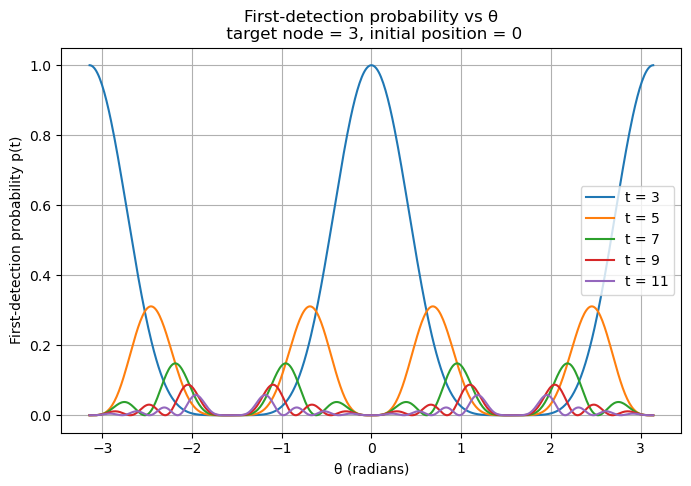

In [5]:
# t values (start at t = target position, increase by 2).
target = int(input("Enter target node: "))
init_pos = int(input("Enter initial position: "))
t_values = range(target, target + 10, 2)

plt.figure(figsize=(8, 5))

for t in t_values:

    p_vals = []

    for theta in theta_vals:

        R = rotation(theta)
        U = S @ kron(np.eye(Npos, dtype=complex), R)

        if init_pos == target:
            if t == 0:
                p_t = 1.0
            else:
                p_t = 0.0
        else:
            QU = Q @ U
            QU_power = np.linalg.matrix_power(QU, t - 1)

            A = P @ U @ QU_power
            B = dagger(A)

            p_t = np.real(np.trace(A @ rho0 @ B))

        p_vals.append(p_t)

    plt.plot(theta_vals, p_vals, label=f"t = {t}")

plt.xlabel("θ (radians)")
plt.ylabel("First-detection probability p(t)")
plt.title(f"First-detection probability vs θ\n target node = {target}, initial position = {init_pos}")
plt.legend()
plt.grid()
plt.show()

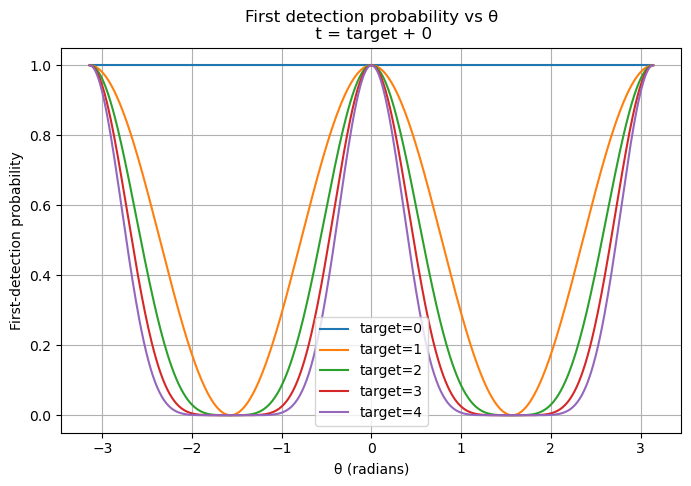

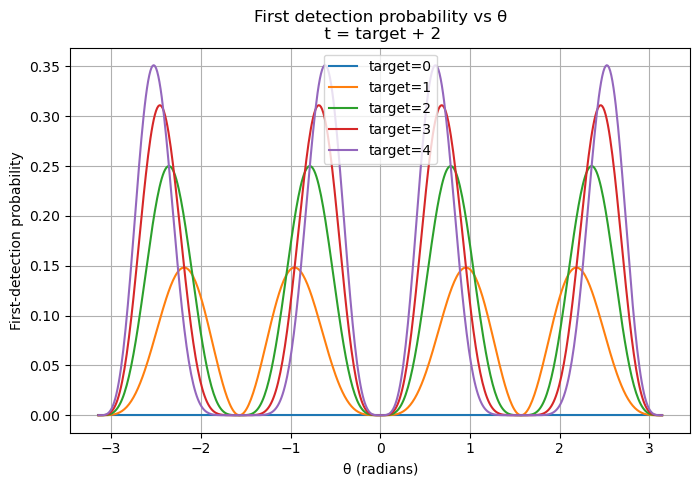

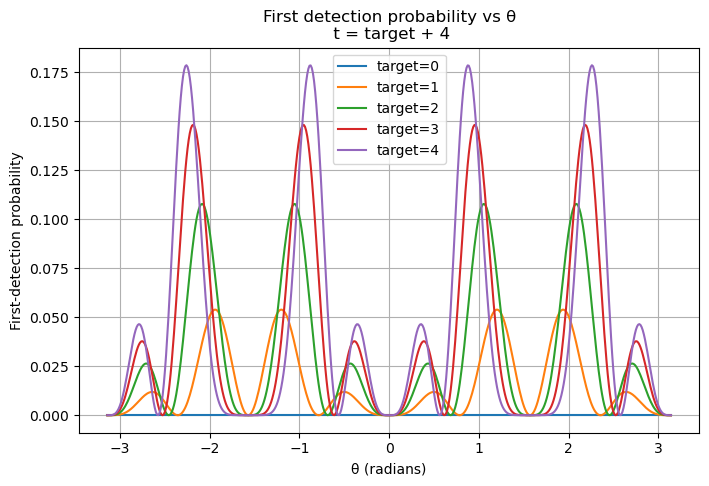

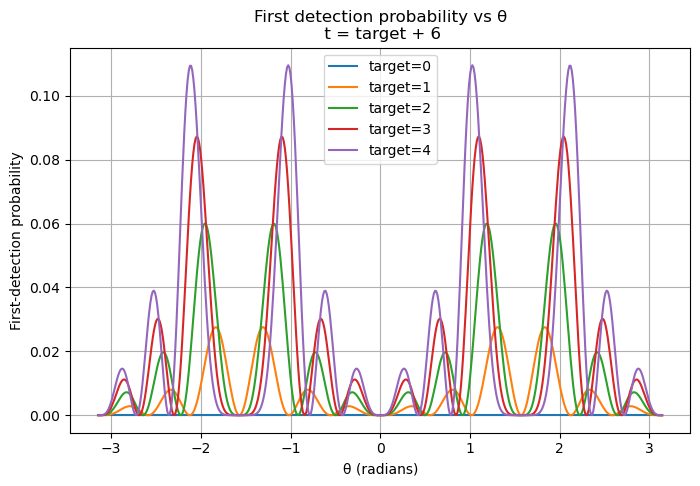

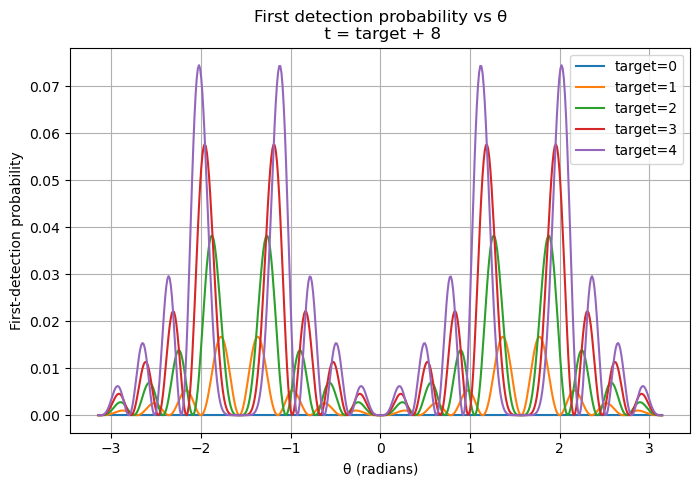

In [6]:
targets = [0,1,2,3,4]
t_offsets = [0,2,4,6,8]

for offset in t_offsets:

    plt.figure(figsize=(8,5))   # new graph for each t case

    curve_store = {}
    
    for target in targets:

        # projection operators
        P_pos = np.zeros((Npos, Npos), dtype=complex)
        P_pos[pos_index(target), pos_index(target)] = 1

        I_coin = np.eye(2, dtype=complex)
        P = kron(P_pos, I_coin)
        Q = np.eye(dim, dtype=complex) - P

        # time for this case
        t = target + offset

        p_vals = []

        for theta in theta_vals:

            R = rotation(theta)
            U = S @ kron(np.eye(Npos, dtype=complex), R)

            if init_pos == target:
                if t == 0:
                    p_t = 1.0
                else:
                    p_t = 0.0
            else:
                QU = Q @ U
                QU_power = np.linalg.matrix_power(QU, t - 1)

                A = P @ U @ QU_power
                B = dagger(A)

                p_t = np.real(np.trace(A @ rho0 @ B))

            p_vals.append(p_t)
       
        p_vals = np.array(p_vals)

        curve_store[target] = p_vals
        plt.plot(theta_vals, p_vals, label=f"target={target}")

    plt.xlabel("θ (radians)")
    plt.ylabel("First-detection probability")
    plt.title(f"First detection probability vs θ\n t = target + {offset}")
    plt.legend()
    plt.grid()
    plt.show()